# G1.2 沪深300历史成分有效区间

**Notebook 类型：** 数据工程审计 + 教学式实验日志  
**研究问题：** 如何从月末权重快照还原无幸存者偏差的 point-in-time 股票池？  
**输入：** 冻结的138个月度权重快照、交易所日历、官方调样规则与临时事件台账  
**输出：** 成分调整事件、有效区间、周频股票池、月末对账报告

## tl;dr

历史成分区间已通过本步全部门禁：

- 2015—2025 共解释26次调整：22次定期调整、4次临时调整；
- 构造750条左闭右开的连续区间，覆盖657只历史成分股；
- 132个月末快照全部精确对账；
- 563个周频信号日均恰好映射300只，共168,900条信号—成分记录；
- 主键重复为0；临时调整前后的旧成员/新成员归属全部正确。

“哪些股票发生变化”来自冻结快照差分，“何时生效”来自中证规则和
经核实的临时事件日期。两类证据分开记录，避免把月末观察日误当生效日。

## Context & Methods

### 为什么月末快照不能直接前向填充

假设六月定期调整在月中生效，但数据库只保存5月末与6月末权重。
如果把5月末快照一直填充到6月末，就会把月中至月末的股票池全部错配。
正确做法是：

1. 对相邻快照做集合差分，识别调入和调出；
2. 根据指数规则或临时公告确定真实生效日；
3. 构造左闭右开区间 `[effective_start, effective_end_exclusive)`；
4. 在每个信号日查询当时有效的区间。

### Key Assumptions

- 2015年1月快照回溯作为2015-01-01基线；1—4月快照必须完全一致。
- 定期调整：每年6月和12月第二个星期五后的首个交易日生效。
- 临时调整：使用事件台账中核实的退市/调整生效日。
- 月末权重只用于识别成员集合，不作为模型或Top50组合权重。
- 原始指数成分和模型可用样本分开保存；本步只构建 `is_index_member`。

## Data

### 1. 加载配置、证据台账与可复用模块

In [1]:
from pathlib import Path
import json
import sys

from IPython.display import Markdown, display
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd().resolve().parent
if PROJECT_DIR.name != "alpha158_project":
    raise RuntimeError(
        "请从 notebooks 目录执行本 Notebook；当前目录为 "
        f"{Path.cwd().resolve()}"
    )

sys.path.insert(0, str(PROJECT_DIR / "src"))
from alpha158_research.universe import (
    build_adjustment_events,
    build_membership_intervals,
    membership_on_dates,
    reconcile_snapshot_sets,
    snapshot_changes,
)

DATA_LAKE = Path("/Users/mingyuxu/Desktop/因子挖掘/data_lake/tushare")
BUILD_MANIFEST = DATA_LAKE / "manifests/build-run-20260722T150836595381-c8eddf4e.json"
RESEARCH_CONFIG = PROJECT_DIR / "config/research_v1.json"
EVENT_CONFIG = PROJECT_DIR / "config/csi300_membership_events_v1.json"
WEEKLY_CALENDAR_PATH = PROJECT_DIR / "artifacts/G1/weekly_calendar_g1_1.parquet"
ARTIFACT_DIR = PROJECT_DIR / "artifacts/G1"

build_manifest = json.loads(BUILD_MANIFEST.read_text(encoding="utf-8"))
research_config = json.loads(RESEARCH_CONFIG.read_text(encoding="utf-8"))
event_config = json.loads(EVENT_CONFIG.read_text(encoding="utf-8"))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Hiragino Sans GB", "STHeiti"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 100)

### 2. 读取冻结权重快照和交易日历

In [2]:
connection = duckdb.connect(database=":memory:")
membership_path = Path(
    build_manifest["reference"]["files"]["index_weight_000300_SH"]["path"]
)
trade_calendar_path = Path(
    build_manifest["reference"]["files"]["trade_calendar"]["path"]
)

membership = connection.execute(
    '''
    SELECT
        index_code,
        con_code,
        STRPTIME(trade_date, '%Y%m%d')::DATE AS snapshot_date,
        weight
    FROM read_parquet(?)
    ORDER BY snapshot_date, con_code
    ''',
    [str(membership_path)],
).fetchdf()
membership["snapshot_date"] = pd.to_datetime(membership["snapshot_date"])

trade_calendar = connection.execute(
    '''
    SELECT STRPTIME(cal_date, '%Y%m%d')::DATE AS trade_date
    FROM read_parquet(?)
    WHERE exchange = 'SSE' AND is_open = 1
    ORDER BY trade_date
    ''',
    [str(trade_calendar_path)],
).fetchdf()
open_dates = pd.DatetimeIndex(pd.to_datetime(trade_calendar["trade_date"]))

weekly_calendar = pd.read_parquet(WEEKLY_CALENDAR_PATH)
weekly_calendar["signal_date"] = pd.to_datetime(weekly_calendar["signal_date"])

profile = pd.DataFrame(
    [
        ("月度快照数", membership["snapshot_date"].nunique()),
        ("权重记录数", len(membership)),
        ("快照最少成分数", membership.groupby("snapshot_date")["con_code"].nunique().min()),
        ("快照最多成分数", membership.groupby("snapshot_date")["con_code"].nunique().max()),
        ("重复快照成分键", membership.duplicated(["snapshot_date", "con_code"]).sum()),
        ("周频信号数", len(weekly_calendar)),
    ],
    columns=["检查", "结果"],
)
profile

,检查,结果
0,月度快照数,138
1,权重记录数,41400
2,快照最少成分数,300
3,快照最多成分数,300
4,重复快照成分键,0
5,周频信号数,563


### 3. 展示临时调整证据

In [3]:
evidence_rows = []
for event in event_config["temporary_adjustments"]:
    evidence_rows.append(
        {
            "event_id": event["event_id"],
            "effective_date": event["effective_date"],
            "removed": ", ".join(event["removed"]),
            "added": ", ".join(event["added"]),
            "effective_date_sources": len(event["effective_date_evidence"]),
            "snapshot_evidence": event["membership_delta_evidence"],
        }
    )
temporary_evidence = pd.DataFrame(evidence_rows)
temporary_evidence

,event_id,effective_date,removed,added,effective_date_sources,snapshot_evidence
0,TEMP_2015_05_20,2015-05-20,"600832.SH, 601299.SH","000738.SZ, 300003.SZ",3,Frozen monthly snapshot change from 2015-04-30 to 2015-05-29.
1,TEMP_2017_02_14,2017-02-14,600005.SH,600549.SH,2,Frozen monthly snapshot change from 2017-01-26 to 2017-02-28.
2,TEMP_2025_03_04,2025-03-04,600837.SH,601058.SH,2,Frozen monthly snapshot change from 2025-02-28 to 2025-03-31.
3,TEMP_2025_09_05,2025-09-05,601989.SH,601298.SH,2,Frozen monthly snapshot change from 2025-08-29 to 2025-09-30.


In [4]:
source_rows = []
for event in event_config["temporary_adjustments"]:
    for source in event["effective_date_evidence"]:
        source_rows.append(
            {
                "event_id": event["event_id"],
                "authority": source["authority"],
                "supports": source["supports"],
                "url": source["url"],
            }
        )
evidence_sources = pd.DataFrame(source_rows)
evidence_sources

,event_id,authority,supports,url
0,TEMP_2015_05_20,Shanghai Stock Exchange and China Securities Index,Index samples change from the delisting date.,https://www.sse.com.cn/market/sseindex/diclosure/c/c_20150911_3985142.shtml
1,TEMP_2015_05_20,Shanghai Securities News reproducing the SSE delisting announcement,Oriental Pearl delisting date is 2015-05-20.,https://paper.cnstock.com/html/2015-05/18/content_530710.htm
2,TEMP_2015_05_20,Company announcement archive,The original company announcement identifies 2015-05-20 as the delisting date.,https://money.finance.sina.com.cn/corp/view/vCB_AllBulletinDetail.php?id=1791463&stockid=600832
3,TEMP_2017_02_14,Shanghai Stock Exchange and China Securities Index,The index adjustment takes effect on the 2017-02-14 delisting date.,https://www.sse.com.cn/market/sseindex/diclosure/c/c_20170209_4235948.shtml
4,TEMP_2017_02_14,Shanghai Stock Exchange,Wuhan Iron and Steel is delisted on 2017-02-14.,https://www.sse.com.cn/disclosure/announcement/listing/c/c_20170208_4235564.shtml
5,TEMP_2025_03_04,Shanghai Stock Exchange,Haitong Securities is delisted on 2025-03-04.,https://www.sse.com.cn/disclosure/announcement/listing/stock/c/c_20250226_10773005.shtml
6,TEMP_2025_03_04,Issuer report reproduced by Sina Finance,Sailun Group enters CSI 300 on 2025-03-04.,https://finance.sina.com.cn/stock/relnews/cn/2025-03-04/doc-inennqmm8628146.shtml
7,TEMP_2025_09_05,Shanghai Stock Exchange,China Shipbuilding Industry is delisted on 2025-09-05.,https://big5.sse.com.cn/site/cht/www.sse.com.cn/disclosure/announcement/listing/stock/c/c_202508...
8,TEMP_2025_09_05,Issuer report reproduced by Sina Finance,Qingdao Port enters CSI 300 on 2025-09-05.,https://finance.sina.com.cn/stock/relnews/hk/2025-09-08/doc-infpuftn6264331.shtml


## Results

### 4. 将快照变化映射为真实生效事件

非6月/12月的变化必须精确匹配临时事件台账，否则程序立即报错并阻断 G1。

In [5]:
all_snapshot_changes = snapshot_changes(membership)
observed_changes = all_snapshot_changes.loc[
    (all_snapshot_changes["added_count"] > 0)
    | (all_snapshot_changes["removed_count"] > 0)
].copy()
observed_changes = observed_changes.loc[
    observed_changes["snapshot_date"].dt.year.between(2015, 2025)
]

events = build_adjustment_events(
    membership,
    open_dates,
    event_config["temporary_adjustments"],
    start_year=2015,
    end_year=2025,
)
events_frame = pd.DataFrame([event.as_record() for event in events])

event_type_summary = (
    events_frame.groupby("event_type", as_index=False)
    .agg(
        events=("event_id", "size"),
        additions=("added_count", "sum"),
        removals=("removed_count", "sum"),
    )
)

assert len(observed_changes) == 26
assert (events_frame["event_type"] == "regular").sum() == 22
assert (events_frame["event_type"] == "temporary").sum() == 4
assert (events_frame["added_count"] == events_frame["removed_count"]).all()
event_type_summary

,event_type,events,additions,removals
0,regular,22,445,445
1,temporary,4,5,5


In [6]:
events_frame[
    [
        "event_id",
        "event_type",
        "effective_date",
        "previous_snapshot",
        "snapshot_date",
        "added_count",
        "removed_count",
    ]
]

,event_id,event_type,effective_date,previous_snapshot,snapshot_date,added_count,removed_count
0,TEMP_2015_05_20,temporary,2015-05-20,2015-04-30,2015-05-29,2,2
1,REG_2015_06,regular,2015-06-15,2015-05-29,2015-06-30,18,18
2,REG_2015_12,regular,2015-12-14,2015-11-30,2015-12-31,21,21
3,REG_2016_06,regular,2016-06-13,2016-05-31,2016-06-30,24,24
4,REG_2016_12,regular,2016-12-12,2016-11-30,2016-12-30,30,30
5,TEMP_2017_02_14,temporary,2017-02-14,2017-01-26,2017-02-28,1,1
6,REG_2017_06,regular,2017-06-12,2017-05-31,2017-06-30,30,30
7,REG_2017_12,regular,2017-12-11,2017-11-30,2017-12-29,24,24
8,REG_2018_06,regular,2018-06-11,2018-05-31,2018-06-29,27,27
9,REG_2018_12,regular,2018-12-17,2018-11-30,2018-12-28,24,24


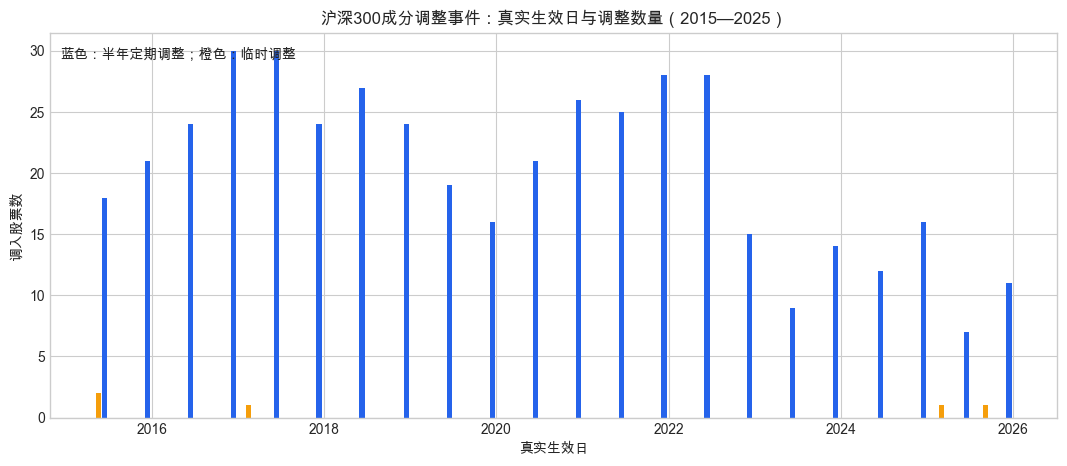

In [7]:
colors = events_frame["event_type"].map(
    {"regular": "#2563EB", "temporary": "#F59E0B"}
)
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(
    events_frame["effective_date"],
    events_frame["added_count"],
    width=22,
    color=colors,
)
ax.set_title("沪深300成分调整事件：真实生效日与调整数量（2015—2025）")
ax.set_xlabel("真实生效日")
ax.set_ylabel("调入股票数")
ax.text(
    0.01,
    0.96,
    "蓝色：半年定期调整；橙色：临时调整",
    transform=ax.transAxes,
    va="top",
)
plt.show()

### 5. 验证2015年基线假设

In [8]:
early_snapshots = membership.loc[
    membership["snapshot_date"].between("2015-01-01", "2015-04-30")
]
early_sets = early_snapshots.groupby("snapshot_date")["con_code"].apply(set)
baseline_members = set(early_sets.iloc[0])
baseline_comparison = pd.DataFrame(
    {
        "snapshot_date": early_sets.index,
        "members": early_sets.map(len).values,
        "exactly_matches_january": [
            members == baseline_members for members in early_sets
        ],
    }
)
assert baseline_comparison["exactly_matches_january"].all()
baseline_comparison

,snapshot_date,members,exactly_matches_january
0,2015-01-30,300,True
1,2015-02-27,300,True
2,2015-03-31,300,True
3,2015-04-30,300,True


### 6. 构造左闭右开的历史成分区间

In [9]:
intervals = build_membership_intervals(
    baseline_members,
    events,
    interval_start="2015-01-01",
    interval_end_exclusive="2026-01-01",
    expected_constituents=300,
)

interval_summary = pd.DataFrame(
    [
        ("区间记录数", len(intervals)),
        ("历史出现股票数", intervals["con_code"].nunique()),
        ("发生过再次进入的股票数", int((intervals.groupby("con_code").size() > 1).sum())),
        ("最早生效日", intervals["effective_start"].min().date()),
        ("最终区间结束日（不含）", intervals["effective_end_exclusive"].max().date()),
    ],
    columns=["检查", "结果"],
)
interval_summary

,检查,结果
0,区间记录数,750
1,历史出现股票数,657
2,发生过再次进入的股票数,86
3,最早生效日,2015-01-01
4,最终区间结束日（不含）,2026-01-01


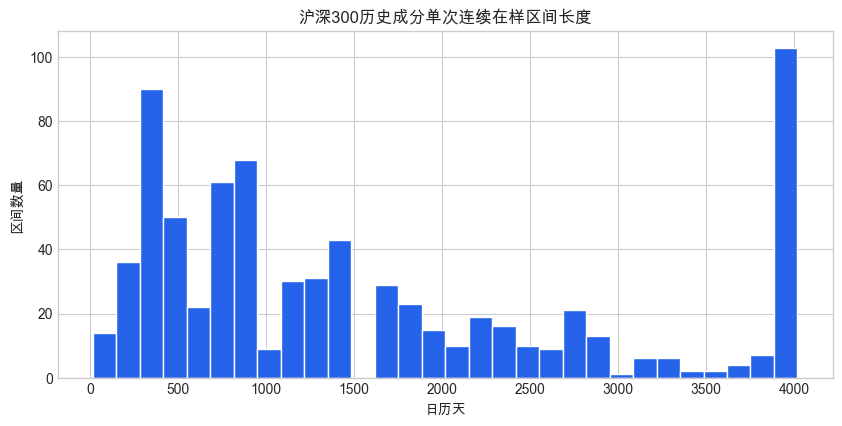

In [10]:
tenure_days = (
    intervals["effective_end_exclusive"] - intervals["effective_start"]
).dt.days
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(tenure_days, bins=30, color="#2563EB", edgecolor="white")
ax.set_title("沪深300历史成分单次连续在样区间长度")
ax.set_xlabel("日历天")
ax.set_ylabel("区间数量")
plt.show()

### 7. 与全部月末快照逐月对账

In [11]:
reconciliation = reconcile_snapshot_sets(
    intervals,
    membership,
    end_date="2025-12-31",
)
assert len(reconciliation) == 132
assert reconciliation["exact_match"].all()
assert (reconciliation["observed_count"] == 300).all()
assert (reconciliation["reconstructed_count"] == 300).all()

reconciliation_summary = pd.DataFrame(
    [
        ("对账快照数", len(reconciliation)),
        ("精确匹配快照数", int(reconciliation["exact_match"].sum())),
        ("不匹配快照数", int((~reconciliation["exact_match"]).sum())),
    ],
    columns=["检查", "结果"],
)
reconciliation_summary

,检查,结果
0,对账快照数,132
1,精确匹配快照数,132
2,不匹配快照数,0


### 8. 在563个周频信号日展开股票池

In [12]:
weekly_membership = membership_on_dates(
    intervals,
    weekly_calendar["signal_date"],
    date_column="signal_date",
)
weekly_counts = (
    weekly_membership.groupby("signal_date", as_index=False)
    .agg(
        constituents=("con_code", "nunique"),
        rows=("con_code", "size"),
    )
)

expected_rows = len(weekly_calendar) * 300
duplicate_weekly_keys = weekly_membership.duplicated(
    ["signal_date", "con_code"]
).sum()
assert len(weekly_membership) == expected_rows
assert duplicate_weekly_keys == 0
assert (weekly_counts["constituents"] == 300).all()
assert (weekly_counts["rows"] == 300).all()

weekly_membership_summary = pd.DataFrame(
    [
        ("信号日", len(weekly_counts)),
        ("信号—成分行数", len(weekly_membership)),
        ("每周最少成分数", weekly_counts["constituents"].min()),
        ("每周最多成分数", weekly_counts["constituents"].max()),
        ("重复信号—成分键", duplicate_weekly_keys),
    ],
    columns=["检查", "结果"],
)
weekly_membership_summary

,检查,结果
0,信号日,563
1,信号—成分行数,168900
2,每周最少成分数,300
3,每周最多成分数,300
4,重复信号—成分键,0


### 9. 检查临时调整前后的周频归属

In [13]:
event_boundary_rows = []
signal_dates = pd.DatetimeIndex(weekly_calendar["signal_date"]).sort_values()
for event in events:
    if event.event_type != "temporary":
        continue
    before_signals = signal_dates[signal_dates < event.effective_date]
    after_signals = signal_dates[signal_dates >= event.effective_date]
    event_boundary_rows.append(
        {
            "event_id": event.event_id,
            "effective_date": event.effective_date,
            "last_signal_before": before_signals.max(),
            "first_signal_after": after_signals.min(),
            "removed": ", ".join(event.removed),
            "added": ", ".join(event.added),
        }
    )
event_boundaries = pd.DataFrame(event_boundary_rows)
event_boundaries

,event_id,effective_date,last_signal_before,first_signal_after,removed,added
0,TEMP_2015_05_20,2015-05-20,2015-05-15,2015-05-22,"600832.SH, 601299.SH","000738.SZ, 300003.SZ"
1,TEMP_2017_02_14,2017-02-14,2017-02-10,2017-02-17,600005.SH,600549.SH
2,TEMP_2025_03_04,2025-03-04,2025-02-28,2025-03-07,600837.SH,601058.SH
3,TEMP_2025_09_05,2025-09-05,2025-08-29,2025-09-05,601989.SH,601298.SH


In [14]:
boundary_checks = []
weekly_sets = weekly_membership.groupby("signal_date")["con_code"].apply(set)
for event in events:
    if event.event_type != "temporary":
        continue
    boundary = event_boundaries.loc[
        event_boundaries["event_id"] == event.event_id
    ].iloc[0]
    before_members = weekly_sets.loc[boundary["last_signal_before"]]
    after_members = weekly_sets.loc[boundary["first_signal_after"]]
    boundary_checks.append(
        {
            "event_id": event.event_id,
            "old_members_present_before": set(event.removed) <= before_members,
            "old_members_absent_after": set(event.removed).isdisjoint(after_members),
            "new_members_absent_before": set(event.added).isdisjoint(before_members),
            "new_members_present_after": set(event.added) <= after_members,
        }
    )
boundary_check_frame = pd.DataFrame(boundary_checks)
assert boundary_check_frame.drop(columns="event_id").all().all()
boundary_check_frame

,event_id,old_members_present_before,old_members_absent_after,new_members_absent_before,new_members_present_after
0,TEMP_2015_05_20,True,True,True,True
1,TEMP_2017_02_14,True,True,True,True
2,TEMP_2025_03_04,True,True,True,True
3,TEMP_2025_09_05,True,True,True,True


### 10. 可视化历史股票池扩展

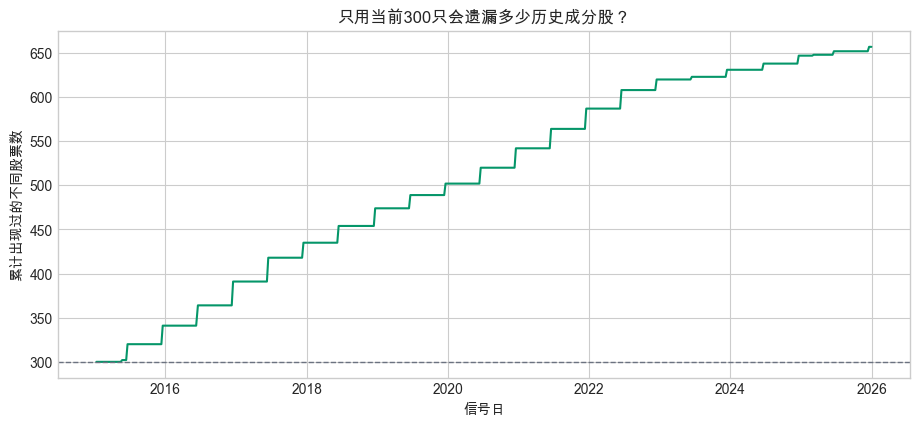

,signal_date,cumulative_unique_members
562,2025-12-31,657


In [15]:
cumulative_unique = []
seen = set()
for signal_date, members in weekly_sets.items():
    seen.update(members)
    cumulative_unique.append(
        {"signal_date": signal_date, "cumulative_unique_members": len(seen)}
    )
cumulative_unique = pd.DataFrame(cumulative_unique)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(
    cumulative_unique["signal_date"],
    cumulative_unique["cumulative_unique_members"],
    color="#059669",
)
ax.axhline(300, color="#6B7280", linestyle="--", linewidth=1)
ax.set_title("只用当前300只会遗漏多少历史成分股？")
ax.set_xlabel("信号日")
ax.set_ylabel("累计出现过的不同股票数")
plt.show()
cumulative_unique.tail(1)

### 11. 保存冻结产物和审计报告

In [16]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

events_output = ARTIFACT_DIR / "csi300_adjustment_events_g1_2.parquet"
intervals_output = ARTIFACT_DIR / "hs300_membership_intervals_g1_2.parquet"
weekly_output = ARTIFACT_DIR / "weekly_hs300_membership_g1_2.parquet"
reconciliation_output = ARTIFACT_DIR / "membership_reconciliation_g1_2.parquet"
audit_output = ARTIFACT_DIR / "membership_audit_g1_2.json"

events_frame.to_parquet(events_output, index=False)
intervals.to_parquet(intervals_output, index=False)
weekly_membership.to_parquet(weekly_output, index=False)
reconciliation.to_parquet(reconciliation_output, index=False)

audit_payload = {
    "stage": "G1.2",
    "status": "pass",
    "index_code": "000300.SH",
    "interval_semantics": event_config["interval_semantics"],
    "baseline_snapshot": event_config["baseline"]["snapshot_date"],
    "events": len(events_frame),
    "regular_events": int((events_frame["event_type"] == "regular").sum()),
    "temporary_events": int((events_frame["event_type"] == "temporary").sum()),
    "interval_rows": len(intervals),
    "historical_unique_members": int(intervals["con_code"].nunique()),
    "monthly_snapshots_reconciled": len(reconciliation),
    "monthly_snapshots_exact_match": int(reconciliation["exact_match"].sum()),
    "weekly_signal_dates": len(weekly_counts),
    "weekly_membership_rows": len(weekly_membership),
    "min_weekly_constituents": int(weekly_counts["constituents"].min()),
    "max_weekly_constituents": int(weekly_counts["constituents"].max()),
    "duplicate_weekly_keys": int(duplicate_weekly_keys),
    "outputs": {
        "events": str(events_output),
        "intervals": str(intervals_output),
        "weekly_membership": str(weekly_output),
        "reconciliation": str(reconciliation_output),
    },
}
audit_output.write_text(
    json.dumps(audit_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
audit_payload

{'stage': 'G1.2',
 'status': 'pass',
 'index_code': '000300.SH',
 'interval_semantics': '[effective_start, effective_end_exclusive)',
 'baseline_snapshot': '2015-01-30',
 'events': 26,
 'regular_events': 22,
 'temporary_events': 4,
 'interval_rows': 750,
 'historical_unique_members': 657,
 'monthly_snapshots_reconciled': 132,
 'monthly_snapshots_exact_match': 132,
 'weekly_signal_dates': 563,
 'weekly_membership_rows': 168900,
 'min_weekly_constituents': 300,
 'max_weekly_constituents': 300,
 'duplicate_weekly_keys': 0,
 'outputs': {'events': '/Users/mingyuxu/Desktop/因子挖掘/factor-mining-experiment-master/local_research/alpha158_project/artifacts/G1/csi300_adjustment_events_g1_2.parquet',
  'intervals': '/Users/mingyuxu/Desktop/因子挖掘/factor-mining-experiment-master/local_research/alpha158_project/artifacts/G1/hs300_membership_intervals_g1_2.parquet',
  'weekly_membership': '/Users/mingyuxu/Desktop/因子挖掘/factor-mining-experiment-master/local_research/alpha158_project/artifacts/G1/weekly_hs3

## Takeaways

In [17]:
display(Markdown(
    f'''
    ### 本步结论

    - 共解释 **{len(events_frame)}** 次调整：
      **{int((events_frame["event_type"] == "regular").sum())}** 次定期调整和
      **{int((events_frame["event_type"] == "temporary").sum())}** 次临时调整。
    - 构造 **{len(intervals):,}** 条连续成分区间，覆盖
      **{intervals["con_code"].nunique()}** 只历史成分股。
    - 2015—2025 的 **{len(reconciliation)}** 个月末快照全部精确对账。
    - **{len(weekly_counts)}** 个信号日均恰好包含300只股票，
      共 **{len(weekly_membership):,}** 条信号—成分记录，重复键为0。

    ### 面试表达

    > 权重数据库提供的是月末观察值，而不是调样事件。
    > 我先对相邻快照做集合差分，再用指数规则和退市公告确定真实生效日，
    > 最终生成左闭右开的历史成分区间。区间结果逐月与132个原始快照对账，
    > 并在563个周频信号日验证每期恰好300只，从源头控制幸存者偏差。

    ### 下一门禁

    历史指数成员已经可用，但模型面板还需要把每周300只进一步映射到：
    行情存在性、60日历史长度、申万行业和总市值可得性。
    这会生成独立的 `is_model_eligible`，不会篡改原始指数成员身份。
    '''
))


    ### 本步结论

    - 共解释 **26** 次调整：
      **22** 次定期调整和
      **4** 次临时调整。
    - 构造 **750** 条连续成分区间，覆盖
      **657** 只历史成分股。
    - 2015—2025 的 **132** 个月末快照全部精确对账。
    - **563** 个信号日均恰好包含300只股票，
      共 **168,900** 条信号—成分记录，重复键为0。

    ### 面试表达

    > 权重数据库提供的是月末观察值，而不是调样事件。
    > 我先对相邻快照做集合差分，再用指数规则和退市公告确定真实生效日，
    > 最终生成左闭右开的历史成分区间。区间结果逐月与132个原始快照对账，
    > 并在563个周频信号日验证每期恰好300只，从源头控制幸存者偏差。

    ### 下一门禁

    历史指数成员已经可用，但模型面板还需要把每周300只进一步映射到：
    行情存在性、60日历史长度、申万行业和总市值可得性。
    这会生成独立的 `is_model_eligible`，不会篡改原始指数成员身份。
    